In [1]:
pip install openpyxl



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install xgboost


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor  # pip install xgboost


df = pd.read_excel("/Users/victorolegario/Downloads/Aluminio_522.xlsx")

print(df.columns)


Index(['PN', 'preco', 'peso_mp', 'peso_peca', 'cavaco', 'comprimento'], dtype='object')


Colunas da base:
Index(['PN', 'preco', 'peso_mp', 'peso_peca', 'cavaco', 'comprimento',
       'faixa'],
      dtype='object')

Quantidade por faixa:
faixa
0    491
1     32
Name: count, dtype: int64

=== Estatísticas gerais da base ===
               preco      peso_mp   peso_peca       cavaco  comprimento  \
count     523.000000   523.000000  523.000000   523.000000   523.000000   
mean     2557.321782    46.292271    2.066530    44.225741   776.483748   
std     10066.504247   237.402147    7.349884   230.615666  1160.097615   
min        48.330000     0.008000    0.001000     0.003000    25.000000   
25%       344.575000     1.149000    0.126500     0.900000   150.000000   
50%       650.330000     3.548000    0.392000     2.834000   305.000000   
75%      1587.255000    11.627000    1.292500    10.594500   645.000000   
max    106450.290000  2933.226000   61.816000  2871.498000  7000.000000   

            faixa  
count  523.000000  
mean     0.061185  
std      0.239900  
min    

,preco,peso_mp,peso_peca,cavaco,comprimento,faixa
count,491.000000,491.000000,491.000000,491.000000,491.000000,491.0
mean,997.753197,9.716895,0.851381,8.865514,711.511202,0.0
std,965.145364,21.151788,1.279729,20.595558,1110.379779,0.0
min,48.330000,0.008000,0.001000,0.003000,25.000000,0.0
25%,336.465000,1.069000,0.117500,0.862000,145.000000,0.0
50%,605.300000,3.098000,0.360000,2.322000,290.000000,0.0
75%,1303.070000,8.736000,0.897500,7.681500,582.500000,0.0
max,4835.270000,308.761000,9.414000,306.638000,7000.000000,0.0



Faixa 1 >5000


,preco,peso_mp,peso_peca,cavaco,comprimento,faixa
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.0
mean,26486.952270,607.495704,20.711469,586.784235,1773.406250,1.0
std,32588.275958,771.788104,22.394621,751.777121,1442.479493,0.0
min,5518.610000,17.139837,1.247000,15.854837,260.000000,1.0
25%,6384.625000,72.535500,2.554000,71.106250,520.000000,1.0
50%,9213.750000,329.531000,8.350500,302.126000,1487.500000,1.0
75%,23290.097500,955.652000,42.777500,911.925000,2440.000000,1.0
max,106450.290000,2933.226000,61.816000,2871.498000,5829.000000,1.0


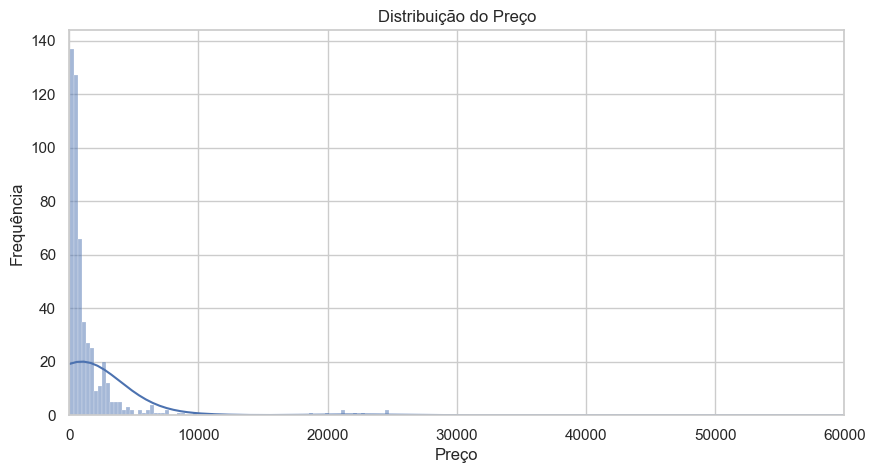

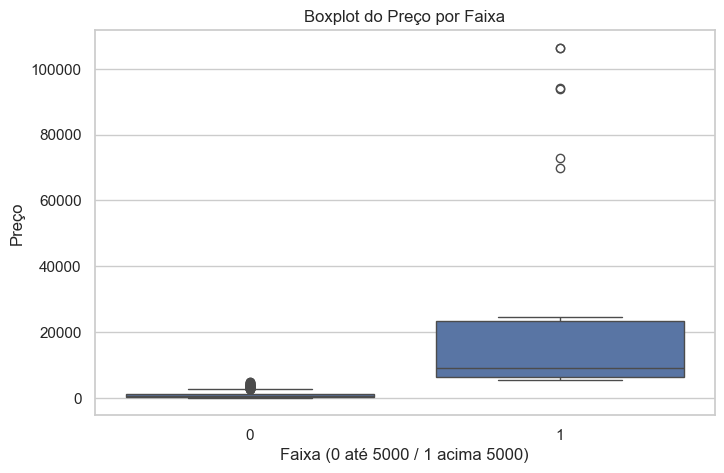

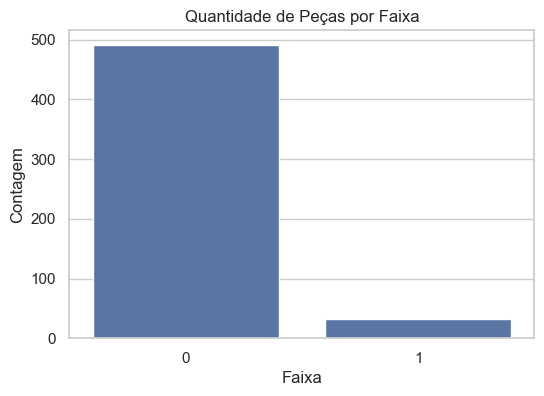

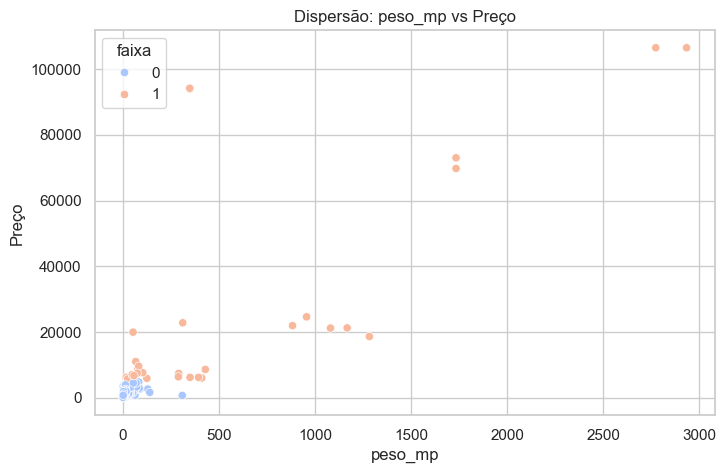

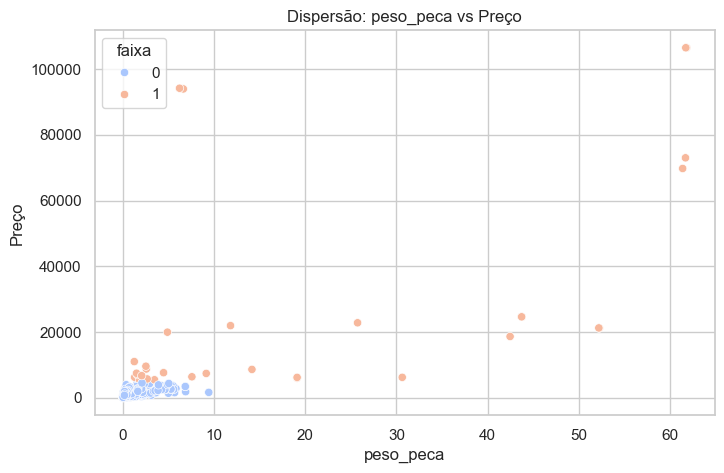

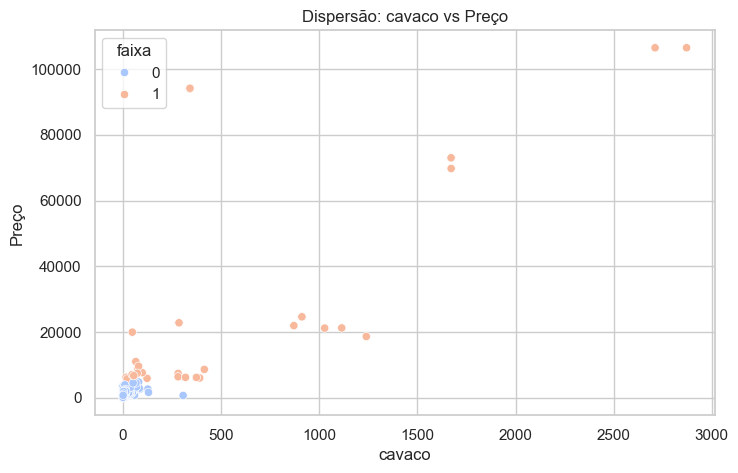

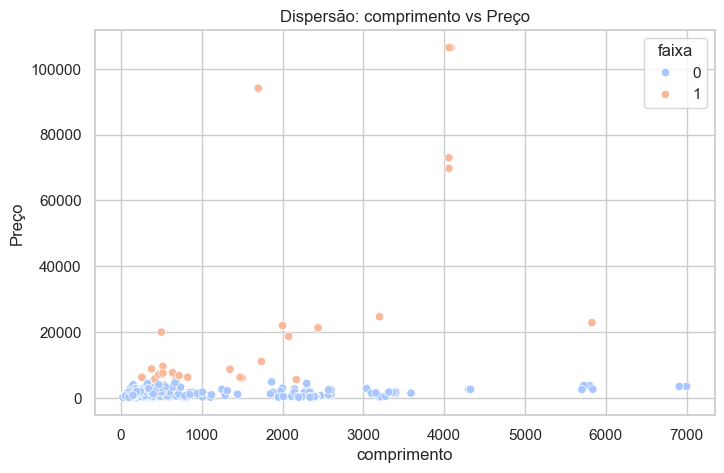

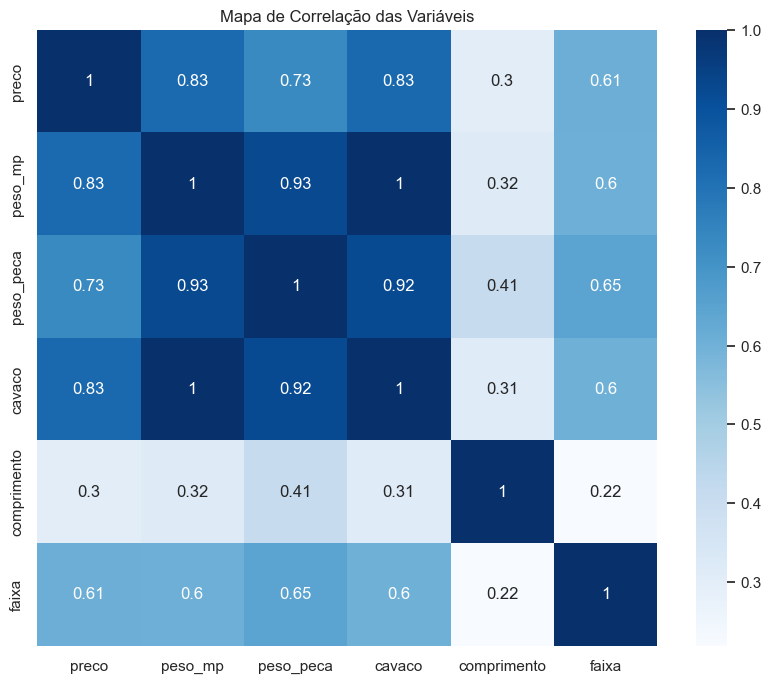

In [ ]:
#!/usr/bin/env python3

sns.set(style="whitegrid")
# =============================================
# 2. CARREGAR DADOS
# =============================================

print("Colunas da base:")
print(df.columns)

# =============================================
# 3. CRIAR FAIXAS DE PREÇO
#    0 -> preco <= 5000
#    1 -> preco > 5000
# =============================================
df["faixa"] = np.where(df["preco"] <= 5000, 0, 1)

print("\nQuantidade por faixa:")
print(df["faixa"].value_counts())

# =============================================
# 4. ESTATÍSTICAS GERAIS
# =============================================
print("\n=== Estatísticas gerais da base ===")
print(df.describe())

# =============================================
# 5. ESTATÍSTICAS POR FAIXA
# =============================================
print("\n=== Estatísticas por faixa ===")

for f in [0, 1]:
    print(f"\nFaixa {f} {'<=5000' if f==0 else '>5000'}")
    display(df[df["faixa"]==f].describe())

# =============================================
# 6. GRÁFICOS
# =============================================

# ---- Distribuição do preço ---
plt.figure(figsize=(10,5))
sns.histplot(df["preco"], kde=True)
plt.title("Distribuição do Preço")
plt.xlabel("Preço")
plt.xlim(0, 60000)

plt.ylabel("Frequência")
plt.show()

# ---- Boxplot por faixa ----
plt.figure(figsize=(8,5))
sns.boxplot(x="faixa", y="preco", data=df)
plt.title("Boxplot do Preço por Faixa")
plt.xlabel("Faixa (0 até 5000 / 1 acima 5000)")
plt.ylabel("Preço")
plt.show()

# ---- Countplot da quantidade por faixa ----
plt.figure(figsize=(6,4))
sns.countplot(x="faixa", data=df)
plt.title("Quantidade de Peças por Faixa")
plt.xlabel("Faixa")
plt.ylabel("Contagem")
plt.show()

# ---- Scatter de cada feature vs preço ----
features_numericas = [col for col in df.columns if df[col].dtype != "object" and col not in ["preco", "faixa"]]

for col in features_numericas:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=df[col], y=df["preco"], hue=df["faixa"], palette="coolwarm")
    plt.title(f"Dispersão: {col} vs Preço")
    plt.xlabel(col)
    plt.ylabel("Preço")
    plt.show()

# ---- Heatmap das correlações ----
plt.figure(figsize=(10,8))
df_num = df.select_dtypes(include=["int64", "float64"])
sns.heatmap(df_num.corr(), annot=True, cmap="Blues")


plt.title("Mapa de Correlação das Variáveis")
plt.show()


=== Estatísticas Descritivas ===
Q1 (25%): 344.58
Q2 (Mediana, 50%): 650.33
Q3 (75%): 1587.26
P90 (90%): 3217.10
Amplitude Interquartil (Q3 - Q1): 1242.68

=== DISTRIBUIÇÃO DE VENDAS POR NOVA FAIXA ===
                 quantidade         media          total  percentual
faixa_valor                                                         
0 - 1.000               333    455.241617  151595.458300   63.671128
1.000 - 5.000           158   2141.147856  338301.361310   30.210325
5.000 - 10.000           17   6914.911765  117553.500000    3.250478
10.000 - 50.000           9  20701.210293  186310.892633    1.720841
Acima de 50.000           6  90619.680000  543718.080000    1.147228


/var/folders/25/ckb5gvk91gz31k04vlbv1x9r0000gn/T/ipykernel_54029/2787172184.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist = df.groupby("faixa_valor")[col_valor].agg(
/var/folders/25/ckb5gvk91gz31k04vlbv1x9r0000gn/T/ipykernel_54029/2787172184.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


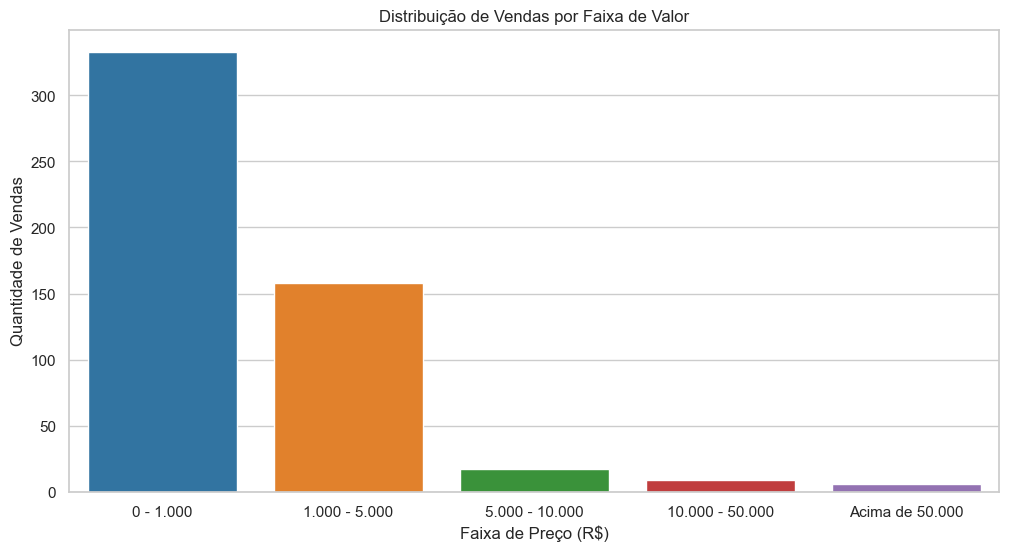


=== OUTLIERS POR IQR (por faixa) ===

Faixa 0 - 1.000: 181 outliers detectados

Faixa 1.000 - 5.000: 34 outliers detectados

Faixa 5.000 - 10.000: 15 outliers detectados

Faixa Acima de 50.000: 0 outliers detectados

Faixa 10.000 - 50.000: 6 outliers detectados

Top 10 outliers globais:
          PN      preco      peso_mp  peso_peca       cavaco  comprimento  \
346  peca347  106450.29  2933.226000     61.728  2871.498000         4060   
343  peca344  106450.29  2772.855516     61.816  2711.039516         4085   
343  peca344  106450.29  2772.855516     61.816  2711.039516         4085   
346  peca347  106450.29  2933.226000     61.728  2871.498000         4060   
343  peca344  106450.29  2772.855516     61.816  2711.039516         4085   
343  peca344  106450.29  2772.855516     61.816  2711.039516         4085   
346  peca347  106450.29  2933.226000     61.728  2871.498000         4060   
346  peca347  106450.29  2933.226000     61.728  2871.498000         4060   
175  peca176   941

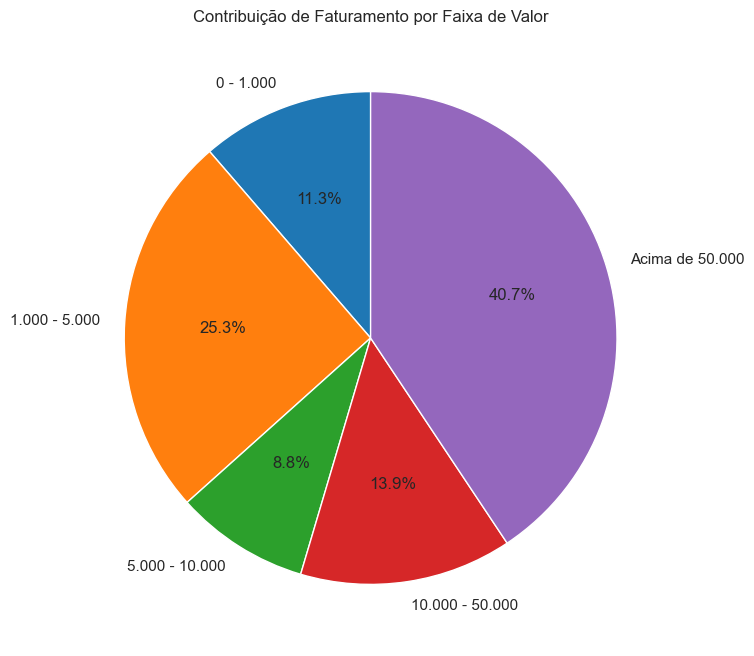


=== CORRELAÇÃO POR FAIXA ===

Correlação — Faixa 0 - 1.000
                preco
preco        1.000000
peso_peca    0.445876
peso_mp      0.199102
cavaco       0.190133
comprimento -0.009236
faixa             NaN

Correlação — Faixa 1.000 - 5.000
                preco
preco        1.000000
peso_peca    0.370755
peso_mp      0.309929
cavaco       0.290362
comprimento  0.204882
faixa             NaN

Correlação — Faixa 5.000 - 10.000
                preco
preco        1.000000
cavaco       0.069459
peso_mp      0.059366
peso_peca   -0.125230
comprimento -0.260337
faixa             NaN

Correlação — Faixa Acima de 50.000
                preco
preco        1.000000
cavaco       0.300875
peso_mp      0.289931
comprimento -0.161612
peso_peca   -0.162364
faixa             NaN

Correlação — Faixa 10.000 - 50.000
                preco
preco        1.000000
peso_peca    0.552278
peso_mp      0.464049
cavaco       0.456792
comprimento  0.449030
faixa             NaN


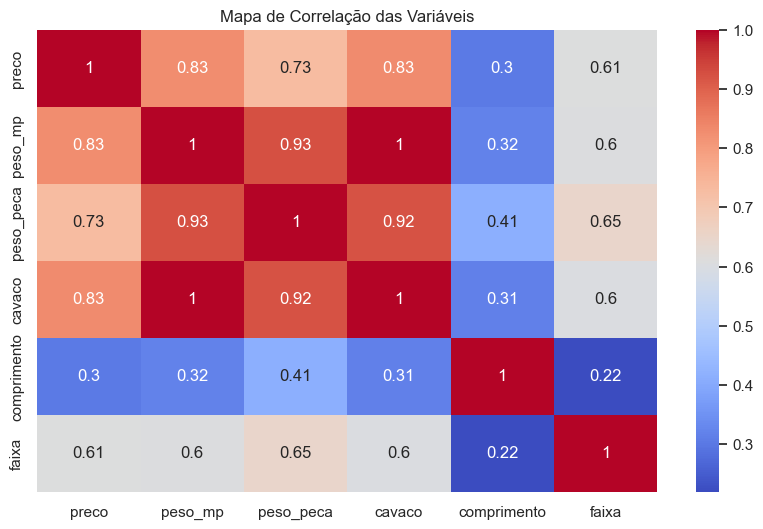

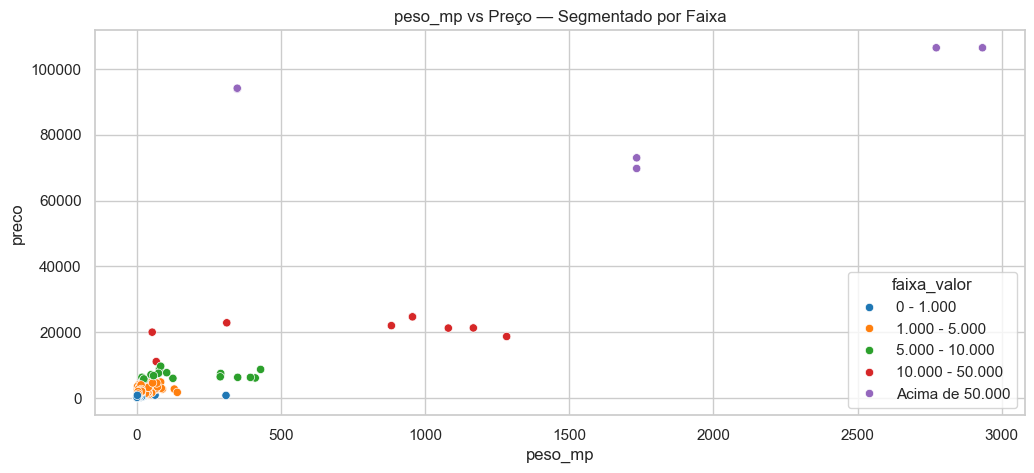

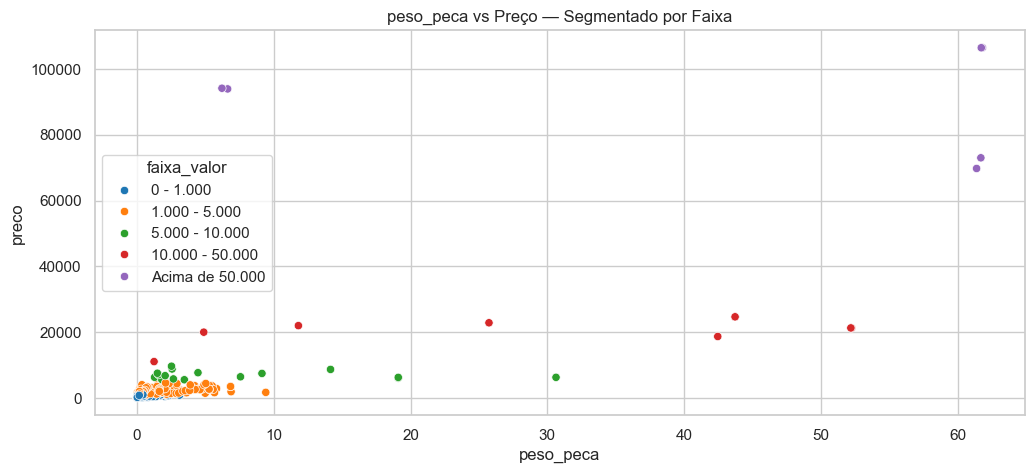

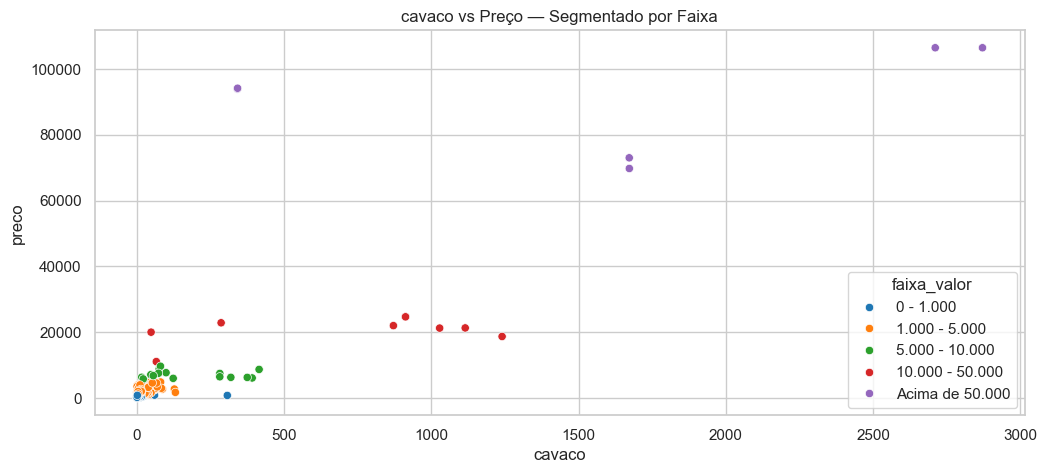

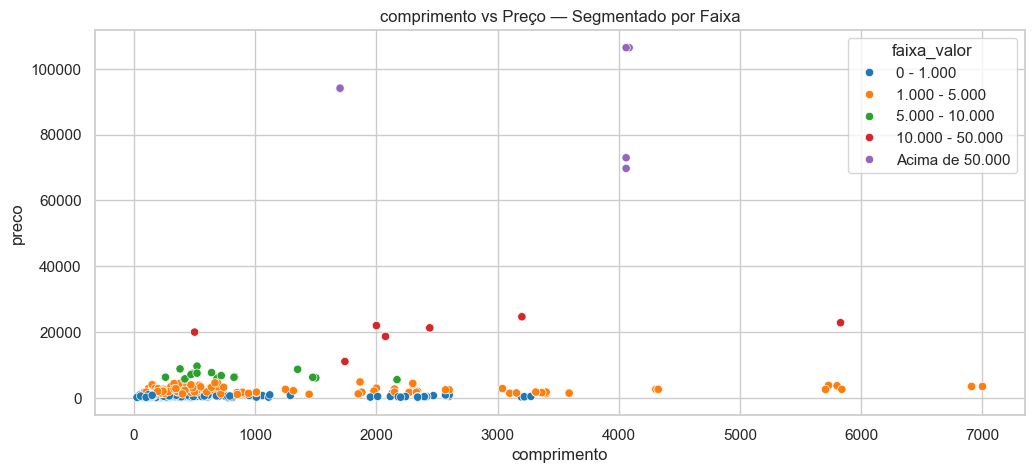

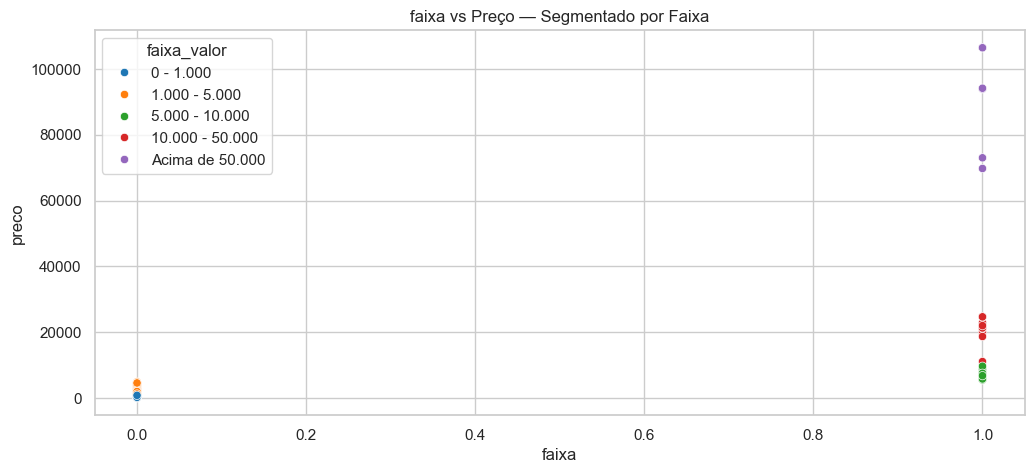

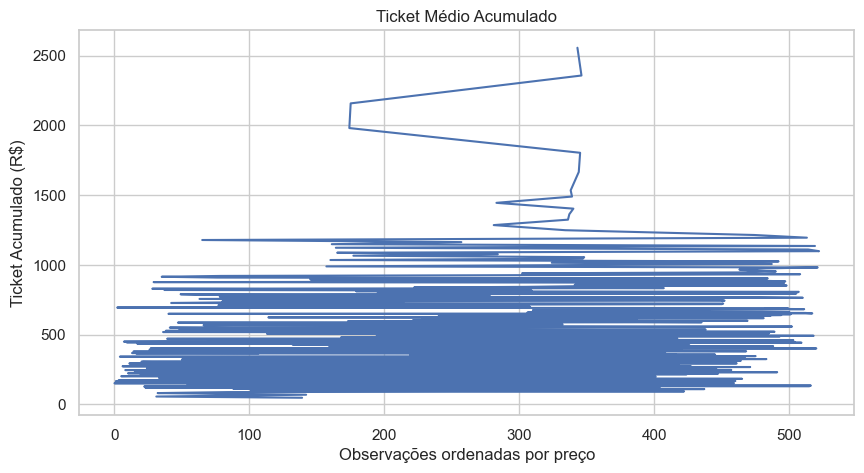


=== RESUMO EXECUTIVO ===
📊 Faixa com mais vendas: 0 - 1.000 (63.67%).
💰 Faixa com maior faturamento: Acima de 50.000 (R$ 543718.08).
🔍 P90 = 3217.10 — apenas 10% das vendas estão acima deste valor.
📉 IQR = 1242.68 — dispersão dos valores intermediários.

=== ANÁLISE POR GRUPO ===
Faixa 0 - 1.000: 333.0 vendas (63.67%), ticket médio R$ 455.24, total R$ 151595.46.
Faixa 1.000 - 5.000: 158.0 vendas (30.21%), ticket médio R$ 2141.15, total R$ 338301.36.
Faixa 5.000 - 10.000: 17.0 vendas (3.25%), ticket médio R$ 6914.91, total R$ 117553.50.
Faixa 10.000 - 50.000: 9.0 vendas (1.72%), ticket médio R$ 20701.21, total R$ 186310.89.
Faixa Acima de 50.000: 6.0 vendas (1.15%), ticket médio R$ 90619.68, total R$ 543718.08.


In [9]:
# ============================================================
#  1) Configurações gerais de visualização
# ============================================================
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# ------------------------------------------------------------
# 2) CRIAÇÃO DAS FAIXAS
# ------------------------------------------------------------
bins = [0, 1000, 5000, 10000, 50000, 99999999]
labels = ["0 - 1.000", "1.000 - 5.000", "5.000 - 10.000",
          "10.000 - 50.000", "Acima de 50.000"]

df["faixa_valor"] = pd.cut(df["preco"], bins=bins, labels=labels, include_lowest=True)

# 🔥 PALETA FIXA PARA TODAS AS FAIXAS
cores_faixa = {
    "0 - 1.000": "#1f77b4",
    "1.000 - 5.000": "#ff7f0e",
    "5.000 - 10.000": "#2ca02c",
    "10.000 - 50.000": "#d62728",
    "Acima de 50.000": "#9467bd"
}

# ============================================================
# 3) ESTATÍSTICAS GERAIS
# ============================================================
print("\n=== Estatísticas Descritivas ===")
col_valor = "preco"

Q1 = df[col_valor].quantile(0.25)
Q2 = df[col_valor].quantile(0.50)
Q3 = df[col_valor].quantile(0.75)
P90 = df[col_valor].quantile(0.90)
IQR = Q3 - Q1

print(f"Q1 (25%): {Q1:.2f}")
print(f"Q2 (Mediana, 50%): {Q2:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"P90 (90%): {P90:.2f}")
print(f"Amplitude Interquartil (Q3 - Q1): {IQR:.2f}")

# ============================================================
# 4) DISTRIBUIÇÃO DE VENDAS POR FAIXA
# ============================================================
dist = df.groupby("faixa_valor")[col_valor].agg(
    quantidade="count",
    media="mean",
    total="sum"
)
dist["percentual"] = (dist["quantidade"] / len(df) * 100)

print("\n=== DISTRIBUIÇÃO DE VENDAS POR NOVA FAIXA ===")
print(dist)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=dist.index,
    y=dist["quantidade"],
    palette=[cores_faixa[i] for i in dist.index]
)
plt.title("Distribuição de Vendas por Faixa de Valor")
plt.xlabel("Faixa de Preço (R$)")
plt.ylabel("Quantidade de Vendas")
plt.show()

# ============================================================
# 5) OUTLIERS POR FAIXA
# ============================================================
print("\n=== OUTLIERS POR IQR (por faixa) ===")

def detectar_outliers(grupo):
    Q1_g = grupo.quantile(0.25)
    Q3_g = grupo.quantile(0.75)
    IQR_g = Q3_g - Q1_g
    limite_superior = Q3_g + 1.5 * IQR_g
    return df[df[col_valor] > limite_superior]

outliers_total = []
for faixa in df["faixa_valor"].unique():
    grupo = df[df["faixa_valor"] == faixa][col_valor]
    O = detectar_outliers(grupo)
    outliers_total.append(O)
    print(f"\nFaixa {faixa}: {len(O)} outliers detectados")

outliers_total = pd.concat(outliers_total)
print("\nTop 10 outliers globais:")
print(outliers_total.sort_values(col_valor, ascending=False).head(10))

# ============================================================
# 6) IMPACTO DAS FAIXAS NO FATURAMENTO
# ============================================================
plt.figure(figsize=(8, 8))
plt.pie(
    dist["total"],
    labels=dist.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[cores_faixa[i] for i in dist.index]
)
plt.title("Contribuição de Faturamento por Faixa de Valor")
plt.show()

# ============================================================
# 7) CORRELAÇÃO GERAL E POR FAIXA
# ============================================================
print("\n=== CORRELAÇÃO POR FAIXA ===")
vars_num = df.select_dtypes(include=["float64", "int64"]).columns

for faixa in df["faixa_valor"].unique():
    subset = df[df["faixa_valor"] == faixa][vars_num]
    print(f"\nCorrelação — Faixa {faixa}")
    print(subset.corr()[[col_valor]].sort_values(by=col_valor, ascending=False))

plt.figure(figsize=(10, 6))
sns.heatmap(df[vars_num].corr(), annot=True, cmap="coolwarm")
plt.title("Mapa de Correlação das Variáveis")
plt.show()

# ============================================================
# 8) SCATTERPLOTS SEGMENTADOS (com cores fixas)
# ============================================================
for col in df.columns:
    if col not in ["preco", "faixa_valor"] and df[col].dtype != "object":
        plt.figure(figsize=(12, 5))
        sns.scatterplot(
            data=df,
            x=col,
            y="preco",
            hue="faixa_valor",
            palette=cores_faixa
        )
        plt.title(f"{col} vs Preço — Segmentado por Faixa")
        plt.show()

# ============================================================
# 9) TICKET ACUMULADO
# ============================================================
df_sorted = df.sort_values(col_valor)
df_sorted["ticket_acumulado"] = df_sorted[col_valor].expanding().mean()

plt.figure(figsize=(10, 5))
plt.plot(df_sorted["ticket_acumulado"])
plt.title("Ticket Médio Acumulado")
plt.xlabel("Observações ordenadas por preço")
plt.ylabel("Ticket Acumulado (R$)")
plt.grid(True)
plt.show()

# ============================================================
# 10) RESUMO EXECUTIVO
# ============================================================
print("\n=== RESUMO EXECUTIVO ===")

faixa_qtde = dist["quantidade"].idxmax()
faixa_fat = dist["total"].idxmax()

print(f"📊 Faixa com mais vendas: {faixa_qtde} ({dist.loc[faixa_qtde, 'percentual']:.2f}%).")
print(f"💰 Faixa com maior faturamento: {faixa_fat} (R$ {dist.loc[faixa_fat, 'total']:.2f}).")
print(f"🔍 P90 = {P90:.2f} — apenas 10% das vendas estão acima deste valor.")
print(f"📉 IQR = {IQR:.2f} — dispersão dos valores intermediários.")

print("\n=== ANÁLISE POR GRUPO ===")
for i, row in dist.iterrows():
    print(
        f"Faixa {i}: {row['quantidade']} vendas ({row['percentual']:.2f}%), "
        f"ticket médio R$ {row['media']:.2f}, total R$ {row['total']:.2f}."
    )


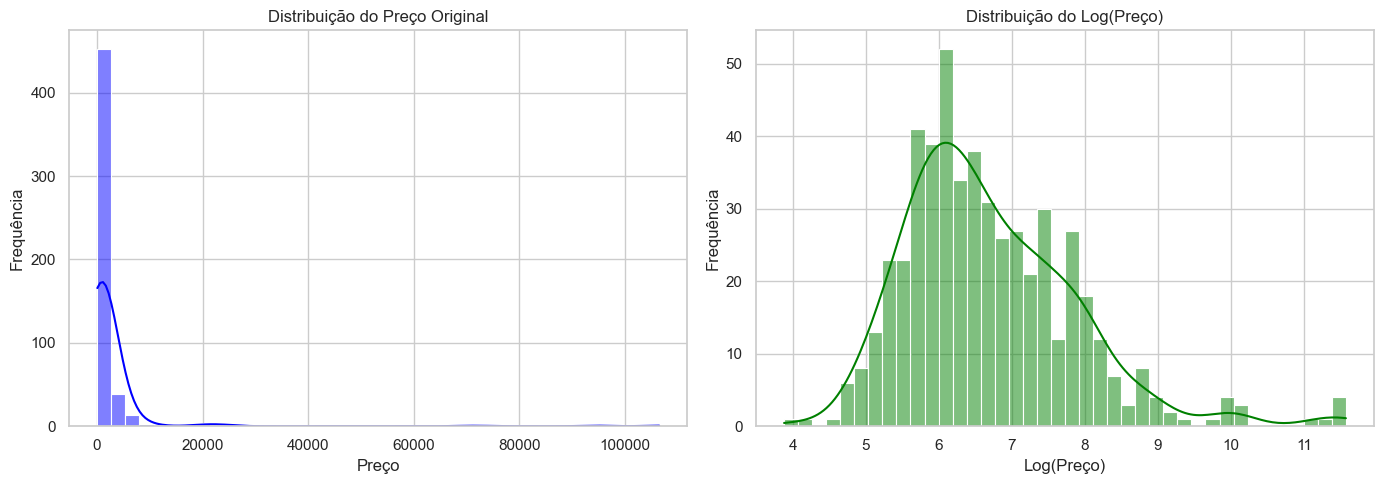

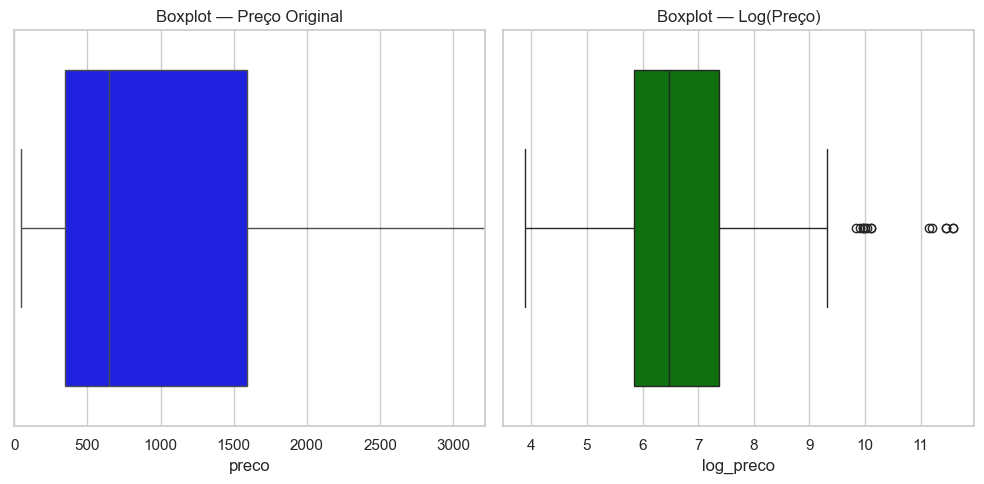


=== Estatísticas do Preço Original ===
count       523.000000
mean       2557.321782
std       10066.504247
min          48.330000
25%         344.575000
50%         650.330000
75%        1587.255000
max      106450.290000
Name: preco, dtype: float64

=== Estatísticas do Log(Preço) ===
count    523.000000
mean       6.690987
std        1.175059
min        3.878052
25%        5.842311
50%        6.477480
75%        7.369751
max       11.575433
Name: log_preco, dtype: float64


In [11]:

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,5)

# Carregar base

# Criar coluna log
df["log_preco"] = np.log(df["preco"])

# ================================
# 1) Histograma — lado a lado
# ================================
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(df["preco"], bins=40, kde=True, color="blue")
plt.title("Distribuição do Preço Original")
plt.xlabel("Preço")
plt.ylabel("Frequência")

plt.subplot(1,2,2)
sns.histplot(df["log_preco"], bins=40, kde=True, color="green")
plt.title("Distribuição do Log(Preço)")
plt.xlabel("Log(Preço)")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

# ================================
# 2) Boxplots comparativos
# ================================
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(x=df["preco"], color="blue")
plt.title("Boxplot — Preço Original")
plt.xlim(0, df["preco"].quantile(0.90))  # corta o extremo

plt.subplot(1,2,2)
sns.boxplot(x=df["log_preco"], color="green")
plt.title("Boxplot — Log(Preço)")

plt.tight_layout()
plt.show()

# ================================
# 3) Estatísticas comparativas
# ================================
print("\n=== Estatísticas do Preço Original ===")
print(df["preco"].describe())

print("\n=== Estatísticas do Log(Preço) ===")
print(df["log_preco"].describe())


In [12]:
# -*- coding: utf-8 -*-
# Random Forest para 2 faixas de preço: <=5000 e >5000


# ============================
# CONFIGURAÇÕES
# ============================
ARQ = "Aluminio_522.xlsx"
FEATURES = ["peso_mp", "peso_peca", "cavaco", "comprimento"]
TARGET = "preco"

# ============================
# Funções auxiliares
# ============================

def to_float_br(x):
    """Converte número em formato Brasil para float."""
    if pd.isna(x):
        return np.nan
    s = re.sub(r"[^\d,.\-]", "", str(x))
    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".")
    elif "," in s:
        s = s.replace(",", ".")
    try:
        return float(s)
    except:
        return np.nan

def mape_safe(y_true, y_pred):
    """MAPE % ignorando zeros."""
    y_true = np.array(y_true, float)
    y_pred = np.array(y_pred, float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_pred[mask] - y_true[mask]) / y_true[mask])) * 100

def rmse(y_true, y_pred):
    y_true = np.array(y_true, float)
    y_pred = np.array(y_pred, float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


# ============================
# 1) Ler e preparar dados
# ============================

df = pd.read_excel(ARQ)
df.columns = [c.strip().lower() for c in df.columns]

all_cols = FEATURES + [TARGET]
faltantes = [c for c in all_cols if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltam colunas: {faltantes}")

# Converter para float
for c in all_cols:
    df[c] = df[c].apply(to_float_br)

df = df.dropna(subset=all_cols).reset_index(drop=True)

# Criar faixas
df["faixa"] = np.where(df[TARGET] <= 5000, 0, 1)

print("\nQuantidade por faixa:")
print(df["faixa"].value_counts())


# ============================
# 2) Modelo Random Forest por faixa
# ============================

predicoes = []
metricas = []

imp = SimpleImputer(strategy="median")

for fx in [0, 1]:
    subset = df[df["faixa"] == fx].reset_index(drop=True)
    
    X = subset[FEATURES].to_numpy(float)
    y = subset[TARGET].to_numpy(float)

    # Imputação
    X_imp = imp.fit_transform(X)

    # Modelo RF
    rf = RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        n_jobs=-1,
        max_depth=None
    )
    rf.fit(X_imp, y)
    y_pred = rf.predict(X_imp)

    # Métricas
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse_val = rmse(y, y_pred)
    mape_val = mape_safe(y, y_pred)

    metricas.append([fx, len(y), r2, mae, rmse_val, mape_val])

    print(f"\n=== Faixa {fx} ({'<=5000' if fx==0 else '>5000'}) ===")
    print(f"n = {len(y)}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse_val:,.2f}")
    print(f"MAPE : {mape_val:.2f}%")

    # Guardar previsões
    temp = subset.copy()
    temp["precofit_rf"] = y_pred
    temp["residuo"] = temp["precofit_rf"] - temp[TARGET]
    temp["erro_abs"] = np.abs(temp["residuo"])
    temp["erro_perc_%"] = np.where(temp[TARGET] != 0, np.abs(temp["residuo"] / temp[TARGET])*100, np.nan)

    predicoes.append(temp)

# Unir todas previsões
final = pd.concat(predicoes, axis=0)
final.to_excel("predicoes_random_forest_faixas.xlsx", index=False)
print("\nArquivo salvo: predicoes_random_forest_faixas.xlsx")

# ============================
# 3) Métricas globais ponderadas
# ============================

metricas_df = pd.DataFrame(metricas, columns=["faixa", "n", "R2", "MAE", "RMSE", "MAPE"])

total = metricas_df["n"].sum()

r2_global = r2_score(df[TARGET], final["precofit_rf"])
mae_global = np.sum(metricas_df["MAE"] * metricas_df["n"]) / total
rmse_global = np.sum(metricas_df["RMSE"] * metricas_df["n"]) / total
mape_global = np.sum(metricas_df["MAPE"] * metricas_df["n"]) / total

print("\n=== Métricas globais (ponderadas) ===")
print(f"R²   : {r2_global:.4f}")
print(f"MAE  : {mae_global:,.2f}")
print(f"RMSE : {rmse_global:,.2f}")
print(f"MAPE : {mape_global:.2f}%")

print("\nTop 10 maiores erros globais:")
cols_show = ["faixa", "preco", "precofit_rf", "erro_abs", "erro_perc_%"]
print(final[cols_show].sort_values("erro_abs", ascending=False).head(10).to_string(index=False))


FileNotFoundError: [Errno 2] No such file or directory: 'Aluminio_522.xlsx'



 TREINANDO — BASE COMPLETA 


Treinando modelo: Linear (log)

Treinando modelo: RandomForest (log)

Treinando modelo: XGBoost (log)

             base              modelo  n_treino  n_teste        R2  \
0  BASE COMPLETA        Linear (log)       418      105 -2.482191   
1  BASE COMPLETA  RandomForest (log)       418      105  0.696954   
2  BASE COMPLETA       XGBoost (log)       418      105  0.679398   

           MAE         RMSE       MAPE  
0  1738.202223  6656.062410  92.841299  
1   738.580017  1963.566474  45.132767  
2   776.904411  2019.639696  50.080542  


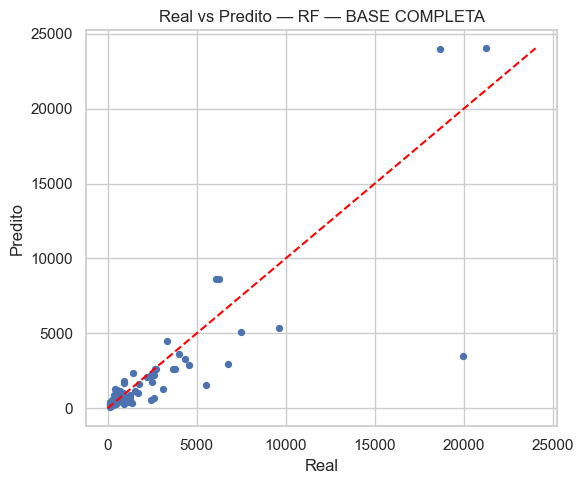



 TREINANDO — FAIXA 0 (<=5000) 


Treinando modelo: Linear (log)

Treinando modelo: RandomForest (log)

Treinando modelo: XGBoost (log)

                base              modelo  n_treino  n_teste        R2  \
0  FAIXA 0 (<=5000)        Linear (log)       392       99  0.352794   
1  FAIXA 0 (<=5000)  RandomForest (log)       392       99  0.581135   
2  FAIXA 0 (<=5000)       XGBoost (log)       392       99  0.521433   

          MAE        RMSE       MAPE  
0  538.885316  886.736624  65.011696  
1  442.249015  713.362502  49.802194  
2  501.988386  762.508518  58.013073  


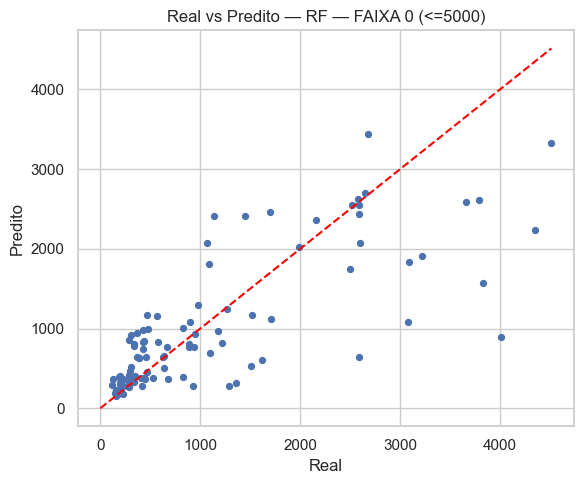



 TREINANDO — FAIXA 1 (>5000) 


Treinando modelo: Linear (log)

Treinando modelo: RandomForest (log)

Treinando modelo: XGBoost (log)

               base              modelo  n_treino  n_teste        R2  \
0  FAIXA 1 (>5000)        Linear (log)        25        7  0.455597   
1  FAIXA 1 (>5000)  RandomForest (log)        25        7  0.443081   
2  FAIXA 1 (>5000)       XGBoost (log)        25        7  0.453081   

           MAE         RMSE       MAPE  
0  3890.428183  5437.440251  31.989249  
1  3484.485008  5499.589420  31.293767  
2  2859.704803  5449.990325  20.168216  


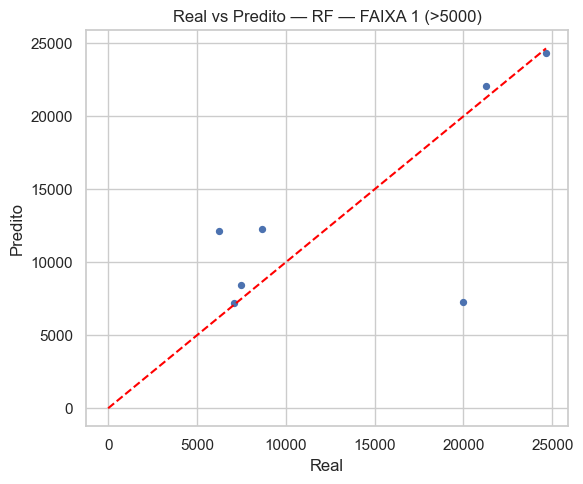



Arquivos gerados:
 - comparacao_modelos_todas_as_bases.xlsx
 - real_vs_predito_rf_base_completa.xlsx
 - real_vs_predito_rf_faixa0.xlsx
 - real_vs_predito_rf_faixa1.xlsx


In [47]:
# -*- coding: utf-8 -*-
# Comparação dos modelos em LOG:
# 1) Base completa
# 2) Faixa 0 (<=5000)
# 3) Faixa 1 (>5000)


# ======================================================
# Funções auxiliares
# ======================================================

def to_float_br(x):
    if pd.isna(x):
        return np.nan
    s = re.sub(r"[^\d,.\-]", "", str(x))
    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".")
    elif "," in s:
        s = s.replace(",", ".")
    return float(s)

def mape_safe(y_true, y_pred):
    y_true = np.array(y_true, float)
    y_pred = np.array(y_pred, float)
    mask = y_true != 0
    return np.mean(np.abs((y_pred[mask] - y_true[mask]) / y_true[mask])) * 100

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


# ======================================================
# 1) Carregar base
# ======================================================

ARQ = "Aluminio_522.xlsx"
FEATURES = ["peso_mp", "peso_peca", "cavaco", "comprimento"]
TARGET = "preco"

df = pd.read_excel(ARQ)
df.columns = [c.strip().lower() for c in df.columns]

for c in FEATURES + [TARGET]:
    df[c] = df[c].apply(to_float_br)

df = df.dropna().reset_index(drop=True)

# Criar faixas
df["faixa"] = np.where(df[TARGET] <= 5000, 0, 1)



# ======================================================
# Função para treinar e avaliar modelos com LOG
# ======================================================

def treinar_modelos(nome_base, dataframe):

    print("\n\n=============================")
    print(f" TREINANDO — {nome_base} ")
    print("=============================\n")

    X = dataframe[FEATURES].to_numpy(float)
    y_real = dataframe[TARGET].to_numpy(float)

    y_log = np.log1p(y_real)

    X_train, X_test, y_train_log, y_test_log, y_train_real, y_test_real = train_test_split(
        X, y_log, y_real, test_size=0.2, random_state=42
    )

    modelos = {
        "Linear (log)": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("reg", LinearRegression())
        ]),
        "RandomForest (log)": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("reg", RandomForestRegressor(
                n_estimators=600, random_state=42, n_jobs=-1
            ))
        ]),
        "XGBoost (log)": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("reg", XGBRegressor(
                n_estimators=600, learning_rate=0.05, max_depth=5,
                subsample=0.8, colsample_bytree=0.8,
                objective="reg:squarederror", random_state=42
            ))
        ])
    }

    resultados = []
    preds_rf = None  # guardar predições do RF

    for nome, model in modelos.items():

        print(f"\nTreinando modelo: {nome}")
        model.fit(X_train, y_train_log)

        y_pred_log = model.predict(X_test)
        y_pred = np.expm1(y_pred_log)

        r2 = r2_score(y_test_real, y_pred)
        mae = mean_absolute_error(y_test_real, y_pred)
        rmse_val = rmse(y_test_real, y_pred)
        mape_val = mape_safe(y_test_real, y_pred)

        resultados.append([nome_base, nome, len(y_train_real), len(y_test_real),
                           r2, mae, rmse_val, mape_val])

        if "RandomForest" in nome:
            preds_rf = pd.DataFrame({
                "preco_real": y_test_real,
                "preco_predito": y_pred,
                "erro_abs": np.abs(y_pred - y_test_real),
                "erro_perc_%": np.abs((y_pred - y_test_real) / y_test_real) * 100
            })

    # Mostrar tabela
    df_res = pd.DataFrame(resultados, columns=[
        "base", "modelo", "n_treino", "n_teste", "R2", "MAE", "RMSE", "MAPE"
    ])
    print("\n", df_res)

    # Gráfico RF
    plt.figure(figsize=(6,5))
    plt.scatter(preds_rf["preco_real"], preds_rf["preco_predito"], s=18)
    lim = [0, max(preds_rf["preco_real"].max(), preds_rf["preco_predito"].max())]
    plt.plot(lim, lim, "--", color="red")
    plt.title(f"Real vs Predito — RF — {nome_base}")
    plt.xlabel("Real")
    plt.ylabel("Predito")
    plt.tight_layout()
    plt.show()

    return df_res, preds_rf



# ======================================================
# RODAR PARA AS TRÊS BASES
# ======================================================

res_base_completa, rf_base_completa = treinar_modelos("BASE COMPLETA", df)
res_faixa0, rf_faixa0 = treinar_modelos("FAIXA 0 (<=5000)", df[df["faixa"] == 0])
res_faixa1, rf_faixa1 = treinar_modelos("FAIXA 1 (>5000)", df[df["faixa"] == 1])



# ======================================================
# Exportar resultados
# ======================================================

pd.concat([res_base_completa, res_faixa0, res_faixa1]).to_excel(
    "comparacao_modelos_todas_as_bases.xlsx", index=False
)

rf_base_completa.to_excel("real_vs_predito_rf_base_completa.xlsx", index=False)
rf_faixa0.to_excel("real_vs_predito_rf_faixa0.xlsx", index=False)
rf_faixa1.to_excel("real_vs_predito_rf_faixa1.xlsx", index=False)

print("\n\nArquivos gerados:")
print(" - comparacao_modelos_todas_as_bases.xlsx")
print(" - real_vs_predito_rf_base_completa.xlsx")
print(" - real_vs_predito_rf_faixa0.xlsx")
print(" - real_vs_predito_rf_faixa1.xlsx")
